In [5]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import astropy_mpl_style, ZScaleInterval, ImageNormalize
file_path_i = 'Berk_i.wcs.proc (1).fits' 
file_path_g = 'Berk_g.wcs.proc (1).fits' 
file_path_r = 'Berk_r.wcs.proc (1).fits' 
hdul_i = fits.open(file_path_i)
hdul_g = fits.open(file_path_g)
hdul_r = fits.open(file_path_r)
image_data_i = hdul_i[0].data
header_i = hdul_i[0].header
print(f"Filter Used_i: {header_i.get('FILTER', 'N/A')}")
image_data_g = hdul_g[0].data
header_g = hdul_g[0].header
print(f"Filter Used_g: {header_g.get('FILTER', 'N/A')}")
image_data_r = hdul_r[0].data
header_r = hdul_r[0].header
print(f"Filter Used_r: {header_r.get('FILTER', 'N/A')}")

Filter Used_i: i
Filter Used_g: g
Filter Used_r: r


In [6]:
import pandas as pd
members = pd.read_csv('confirmed_cluster_members.csv')
print(members.columns)

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'bp_rp', 'ruwe'],
      dtype='object')


In [7]:
from astropy.io import fits
from astropy.wcs import WCS

wcs_dict = {}

for band in ["g", "r", "i"]:
    hdul = fits.open(f"Berk_{band}.wcs.proc (1).fits")
    wcs_dict[band] = WCS(hdul[0].header)

In [8]:
import numpy as np

ra1  = members["ra"].values
dec1 = members["dec"].values

x_g, y_g = wcs_dict["g"].world_to_pixel_values(ra1, dec1)
x_r, y_r = wcs_dict["r"].world_to_pixel_values(ra1, dec1)
x_i, y_i = wcs_dict["i"].world_to_pixel_values(ra1, dec1)

C:\Users\sushm\anaconda3\Lib\site-packages\astropy\wcs\wcsapi\fitswcs.py:346: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))


In [9]:
# g band
ny_g, nx_g = fits.getdata("Berk_g.wcs.proc (1).fits").shape
mask_g = (
    (x_g > 0) & (x_g < nx_g) &
    (y_g > 0) & (y_g < ny_g)
)

# r band
ny_r, nx_r = fits.getdata("Berk_r.wcs.proc (1).fits").shape
mask_r = (
    (x_r > 0) & (x_r < nx_r) &
    (y_r > 0) & (y_r < ny_r)
)

# i band
ny_i, nx_i = fits.getdata("Berk_i.wcs.proc (1).fits").shape
mask_i = (
    (x_i > 0) & (x_i < nx_i) &
    (y_i > 0) & (y_i < ny_i)
)
mask_all = mask_g & mask_r & mask_i


In [10]:
members_in_frame = members[mask_all].copy()

members_in_frame["x_g"] = x_g[mask_all]
members_in_frame["y_g"] = y_g[mask_all]

members_in_frame["x_r"] = x_r[mask_all]
members_in_frame["y_r"] = y_r[mask_all]

members_in_frame["x_i"] = x_i[mask_all]
members_in_frame["y_i"] = y_i[mask_all]

In [21]:
import numpy as np
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std


bkg_sigma = mad_std(image_data_i, ignore_nan=True) #calculates median absolute deviation
daofind = DAOStarFinder(fwhm=3.0, threshold=10.*bkg_sigma)  
sources = daofind(image_data_i)
if sources is not None:
    print("The column names available:", sources.colnames)
     if 'fwhm' in sources.colnames:
        avg_fwhm = np.nanmedian(sources['fwhm'])
    else:
        avg_fwhm = 4.0 
    aperture_radius = 2.0 * avg_fwhm
    print(f"Average FWHM: {avg_fwhm:.2f} pixels")
    print(f"FINAL APERTURE RADIUS: {aperture_radius:.2f} pixels")
else:
    print("No stars found")
    aperture_radius = 6.0 

The column names available: ['id', 'xcentroid', 'ycentroid', 'sharpness', 'roundness1', 'roundness2', 'npix', 'peak', 'flux', 'mag', 'daofind_mag']
Average FWHM: 4.00 pixels
FINAL APERTURE RADIUS: 8.00 pixels


In [12]:
!pip install photutils
from photutils.aperture import CircularAperture, aperture_photometry
image_g = fits.getdata("Berk_g.wcs.proc (1).fits")
positions_g = np.vstack((members_in_frame["x_g"], members_in_frame["y_g"])).T
r_ap = 8.0
apertures_g = CircularAperture(positions_g, r=r_ap)
phot_table_g = aperture_photometry(image_g, apertures_g)
members_in_frame["flux_g"] = phot_table_g["aperture_sum"]
print(phot_table_g[:5])

 id      xcenter            ycenter         aperture_sum   
--- ------------------ ----------------- ------------------
  1 251.16306037490094 762.9086994966823  878.8802065697605
  2  575.4903158105191 645.1971362508547 2386.4587314516507
  3 186.14328159139413 593.5138128784425  998.2229400818026
  4  232.8166173258759 764.5965674465235 1043.1917480851794
  5   395.548217481659 400.5681293165028 1040.3050070752215


In [13]:
# r band
image_r = fits.getdata("Berk_r.wcs.proc (1).fits")
positions_r = np.vstack(
    (members_in_frame["x_r"], members_in_frame["y_r"])
).T

apertures_r = CircularAperture(positions_r, r=r_ap)
phot_table_r = aperture_photometry(image_r, apertures_r)
members_in_frame["flux_r"] = phot_table_r["aperture_sum"]

# i band
image_i = fits.getdata("Berk_i.wcs.proc (1).fits")
positions_i = np.vstack(
    (members_in_frame["x_i"], members_in_frame["y_i"])
).T

apertures_i = CircularAperture(positions_i, r=r_ap)
phot_table_i = aperture_photometry(image_i, apertures_i)
members_in_frame["flux_i"] = phot_table_i["aperture_sum"]
print(phot_table_r[:5])
print(phot_table_i[:5])

 id      xcenter            ycenter         aperture_sum   
--- ------------------ ----------------- ------------------
  1 251.42338184480113 764.1409310379358 1960.3516448298622
  2  575.6665838092313 646.2678368980089 5754.9113398697045
  3  186.3738510963934 594.6496768709426 1931.3138024051618
  4 233.10338667499926 765.8368389393945  1938.622257980545
  5  395.8476893591984 401.4154809510429 2040.6791984612048
 id      xcenter            ycenter         aperture_sum   
--- ------------------ ----------------- ------------------
  1 252.12334600584617 767.7259104605971 1458.7341867253408
  2  576.4507648615696 649.9010640714404  4404.354541552941
  3  187.0465013642801 598.4494765651875 1305.1028688490069
  4 233.79302807214177 769.4240784449186 1297.7823575270654
  5 396.59019979321886 405.0919066203568 1369.0122722753163


In [14]:
print(members_in_frame[["flux_g", "flux_r", "flux_i"]].head())

         flux_g       flux_r       flux_i
32   878.880207  1960.351645  1458.734187
33  2386.458731  5754.911340  4404.354542
83   998.222940  1931.313802  1305.102869
84  1043.191748  1938.622258  1297.782358
85  1040.305007  2040.679198  1369.012272


In [15]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg_g = Background2D(image_g, (50, 50), filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
sky_level_g = bkg_g.background_median 
aperture_area = np.pi * (r_ap**2)
members_in_frame["net_flux_g"] = members_in_frame["flux_g"] - (sky_level_g * aperture_area)

In [16]:
for band, img in zip(['g', 'r', 'i'], [image_g, image_r, image_i]):
    bkg = Background2D(img, (50, 50), filter_size=(3, 3), 
                       sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
    sky_level = bkg.background_median
    
    area = np.pi * (r_ap**2)
    members_in_frame[f"net_flux_{band}"] = members_in_frame[f"flux_{band}"] - (sky_level * area)

for band in ['g', 'r', 'i']:
    net_flux = members_in_frame[f"net_flux_{band}"]
    safe_flux = np.where(net_flux > 0, net_flux, 1.0)
    
    members_in_frame[f"mag_{band}"] = -2.5 * np.log10(safe_flux) + 25.0
members_in_frame['g_r'] = members_in_frame['mag_g'] - members_in_frame['mag_r']
members_in_frame['r_i'] = members_in_frame['mag_r'] - members_in_frame['mag_i']

print(members_in_frame[['mag_g', 'g_r', 'r_i']].head())

        mag_g       g_r       r_i
32  25.000000  5.294215  0.729440
33  17.151361  1.136149 -0.221119
83  25.000000  5.022430  0.010612
84  21.127843  1.225344 -0.144434
85  21.220231  2.033264 -0.256246


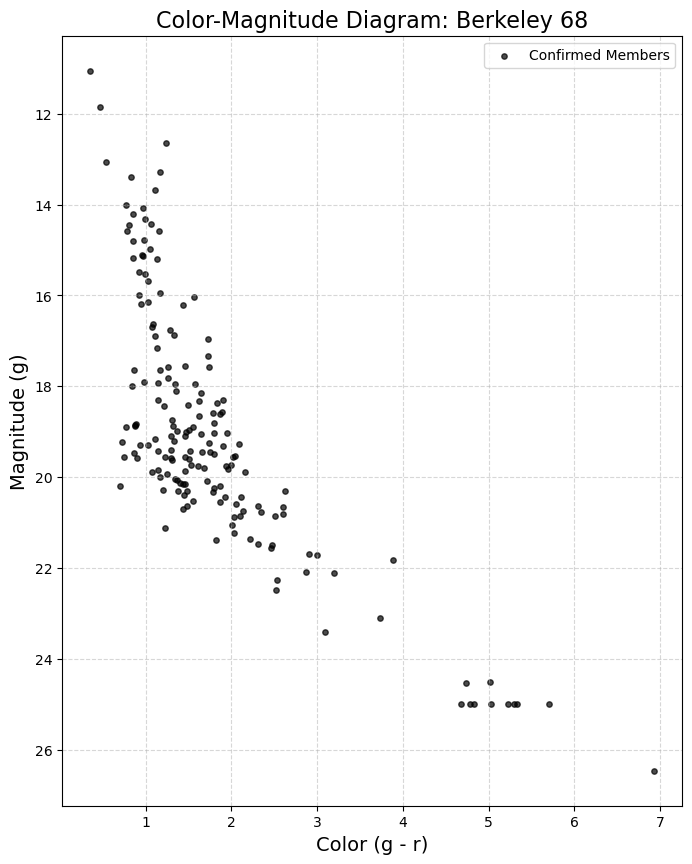

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.scatter(members_in_frame['g_r'], members_in_frame['mag_g'],s=15, color='black', alpha=0.7, label='Confirmed Members')
plt.gca().invert_yaxis()
plt.xlabel('Color (g - r)', fontsize=14)
plt.ylabel('Magnitude (g)', fontsize=14)
plt.title('Color-Magnitude Diagram: Berkeley 68', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

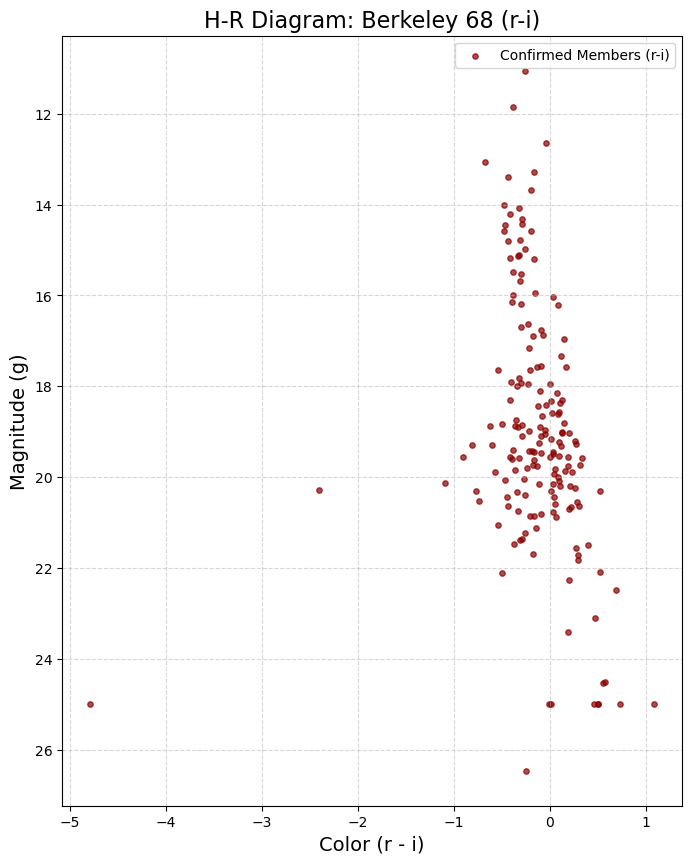

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.scatter(members_in_frame['r_i'], members_in_frame['mag_g'],s=15, color='darkred', alpha=0.7, label='Confirmed Members (r-i)')
plt.gca().invert_yaxis()
plt.xlabel('Color (r - i)', fontsize=14)
plt.ylabel('Magnitude (g)', fontsize=14)
plt.title('H-R Diagram: Berkeley 68 (r-i)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [19]:
# 1. Calculate the color (g - i) for the transformations
members_in_frame['g_i'] = members_in_frame['mag_g'] - members_in_frame['mag_i']
x = members_in_frame['g_i']

# 2. Transformation to Gaia G magnitude (Table 7 coefficients)
# Formula: G = g + [a0 + a1*x + a2*x^2 + a3*x^3]
# Residual: 0.045 mag
a_g = [-0.0638, -0.1352, -0.0469, 0.0039]
members_in_frame['calc_G'] = members_in_frame['mag_g'] + (
    a_g[0] + a_g[1]*x + a_g[2]*x**2 + a_g[3]*x**3
)

# 3. Transformation to Gaia GBP magnitude (Table 7 coefficients)
# Residual: 0.088 mag
a_bp = [0.0462, -0.2185, 0.0125, -0.0016]
members_in_frame['calc_GBP'] = members_in_frame['mag_g'] + (
    a_bp[0] + a_bp[1]*x + a_bp[2]*x**2 + a_bp[3]*x**3
)

# 4. Transformation to Gaia GRP magnitude (Table 7 coefficients)
# Note: This transformation is GRP - i
# Residual: 0.038 mag
a_rp = [-0.0175, -0.3292, 0.0210, -0.0015]
members_in_frame['calc_GRP'] = members_in_frame['mag_i'] + (
    a_rp[0] + a_rp[1]*x + a_rp[2]*x**2 + a_rp[3]*x**3
)

# 5. Calculate the Final Gaia Color
members_in_frame['calc_BP_RP'] = members_in_frame['calc_GBP'] - members_in_frame['calc_GRP']

print("Transformations applied! Ready for Gaia cross-validation.")
print(members_in_frame[['calc_G', 'calc_BP_RP']].head())

Transformations applied! Ready for Gaia cross-validation.
       calc_G  calc_BP_RP
32  23.272465    6.423899
33  16.927568    1.072830
83  23.564914    5.425832
84  20.868032    1.254210
85  20.789962    2.010031


Calculated Zero Point Offset: -1.530 mag


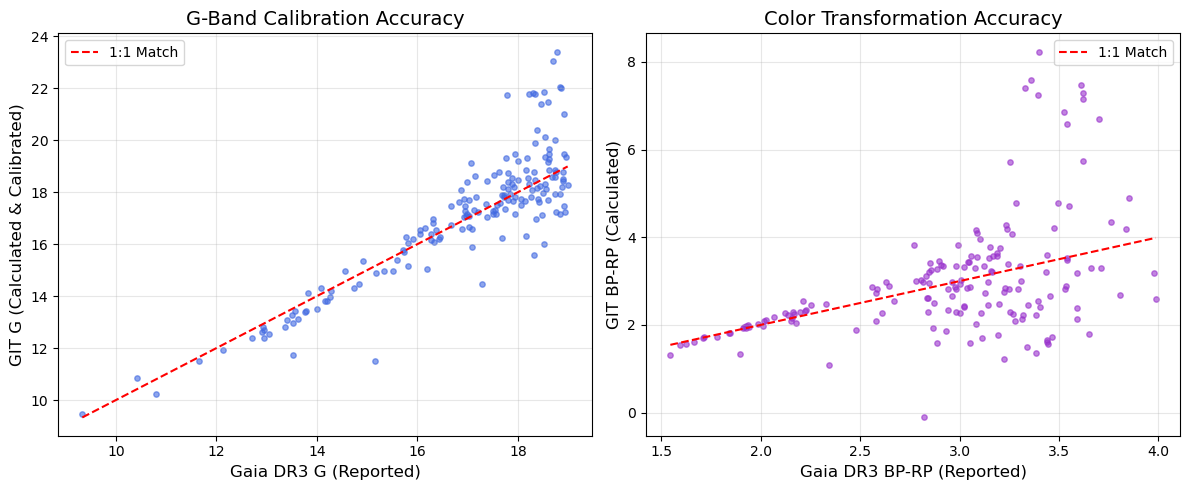

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Offset (Zero Point Calibration)
# This aligns your '25.0' placeholder to the actual brightness seen by Gaia
offset_g = np.nanmedian(members_in_frame['phot_g_mean_mag'] - members_in_frame['calc_G'])
members_in_frame['final_G'] = members_in_frame['calc_G'] + offset_g

print(f"Calculated Zero Point Offset: {offset_g:.3f} mag")

# 2. Plotting the Comparison
plt.figure(figsize=(12, 5))

# Subplot 1: G-magnitude Comparison
plt.subplot(1, 2, 1)
plt.scatter(members_in_frame['phot_g_mean_mag'], members_in_frame['final_G'], 
            s=15, color='royalblue', alpha=0.6)

# Add a 1-to-1 reference line (where a perfect match should be)
lims = [np.min(members_in_frame['phot_g_mean_mag']), np.max(members_in_frame['phot_g_mean_mag'])]
plt.plot(lims, lims, color='red', linestyle='--', label='1:1 Match')

plt.xlabel('Gaia DR3 G (Reported)', fontsize=12)
plt.ylabel('GIT G (Calculated & Calibrated)', fontsize=12)
plt.title('G-Band Calibration Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Color Comparison
# We repeat the process for the BP-RP color
offset_color = np.nanmedian(members_in_frame['bp_rp'] - members_in_frame['calc_BP_RP'])
members_in_frame['final_BP_RP'] = members_in_frame['calc_BP_RP'] + offset_color

plt.subplot(1, 2, 2)
plt.scatter(members_in_frame['bp_rp'], members_in_frame['final_BP_RP'], 
            s=15, color='darkorchid', alpha=0.6)

lims_c = [np.min(members_in_frame['bp_rp']), np.max(members_in_frame['bp_rp'])]
plt.plot(lims_c, lims_c, color='red', linestyle='--', label='1:1 Match')

plt.xlabel('Gaia DR3 BP-RP (Reported)', fontsize=12)
plt.ylabel('GIT BP-RP (Calculated)', fontsize=12)
plt.title('Color Transformation Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()